Imports et Chargement des Données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import joblib

BASE_DIR = Path().resolve().parent
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

# Chargement
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')

# .squeeze() transforme le DataFrame (1 colonne) en Series (vecteur 1D)
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print("Données chargées avec succès !\n")
print(f"X_train : {X_train.shape[0]:,} lignes, {X_train.shape[1]} variables")
print(f"X_test  : {X_test.shape[0]:,} lignes, {X_test.shape[1]} variables")

Données chargées avec succès !

X_train : 15,758 lignes, 14 variables
X_test  : 2,000 lignes, 14 variables


Calcul des Poids et Entraînement

In [2]:
# Calcul dynamique des poids pour compenser le déséquilibre de 1.5%
counts = Counter(y_train)
total  = sum(counts.values())
class_weight = {
    0: total / (2 * counts[0]),
    1: total / (2 * counts[1])
}

print(f"Distribution des classes — Légitime: {counts[0]:,} | Fraude: {counts[1]:,}")
print(f"Poids appliqués (Class Weight) : {class_weight}\n")

# Instanciation
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight=class_weight,
    random_state=42,
    n_jobs=-1 # Utilise tous les cœurs du processeur
)

print("Entraînement du Random Forest en cours...")
rf.fit(X_train, y_train)
print("Entraînement terminé avec succès !")

Distribution des classes — Légitime: 7,879 | Fraude: 7,879
Poids appliqués (Class Weight) : {0: 1.0, 1: 1.0}

Entraînement du Random Forest en cours...
Entraînement terminé avec succès !


Évaluation et Matrice de Confusion

 Score ROC-AUC : 0.9986
 Score PR-AUC  : 0.9325

 Rapport de classification :
              precision    recall  f1-score   support

Légitime (0)       1.00      1.00      1.00      1970
  Fraude (1)       0.81      0.87      0.84        30

    accuracy                           0.99      2000
   macro avg       0.91      0.93      0.92      2000
weighted avg       1.00      0.99      1.00      2000


 Matrice sauvegardée dans : C:\Users\Lenovo T470\OneDrive\Documents\GitHub\fraud-detection-realtime\notebooks\plots\random_forest_confusion_matrix.png


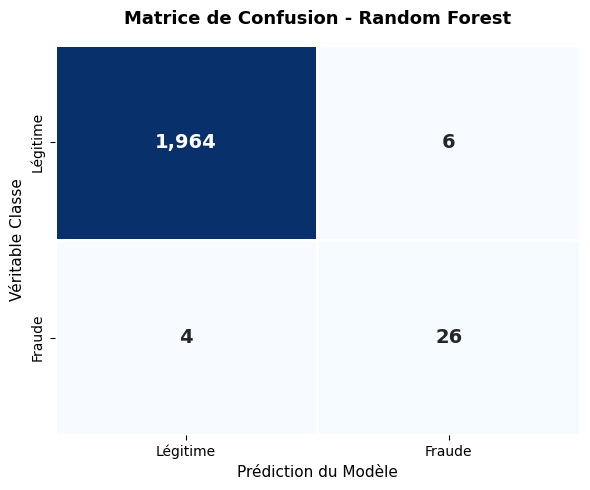

In [3]:
# Prédictions
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

# Métriques
auc_rf   = roc_auc_score(y_test, y_prob_rf)
prauc_rf = average_precision_score(y_test, y_prob_rf)

print(f" Score ROC-AUC : {auc_rf:.4f}")
print(f" Score PR-AUC  : {prauc_rf:.4f}")

print("\n Rapport de classification :")
print(classification_report(y_test, y_pred_rf, target_names=["Légitime (0)", "Fraude (1)"]))

# Matrice de confusion design
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', 
            xticklabels=["Légitime", "Fraude"], 
            yticklabels=["Légitime", "Fraude"],
            linewidths=1, linecolor='white',
            cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax)

ax.set_xlabel("Prédiction du Modèle", fontsize=11)
ax.set_ylabel("Véritable Classe", fontsize=11)
ax.set_title("Matrice de Confusion - Random Forest", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()

# Sauvegarde
PLOT_DIR = BASE_DIR / 'notebooks' / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
save_plot_path = PLOT_DIR / 'random_forest_confusion_matrix.png'

plt.savefig(save_plot_path, bbox_inches='tight', dpi=300)
print(f"\n Matrice sauvegardée dans : {save_plot_path}")
plt.show()

Importance des Variables (Feature Importance)## Calcul du class_weight

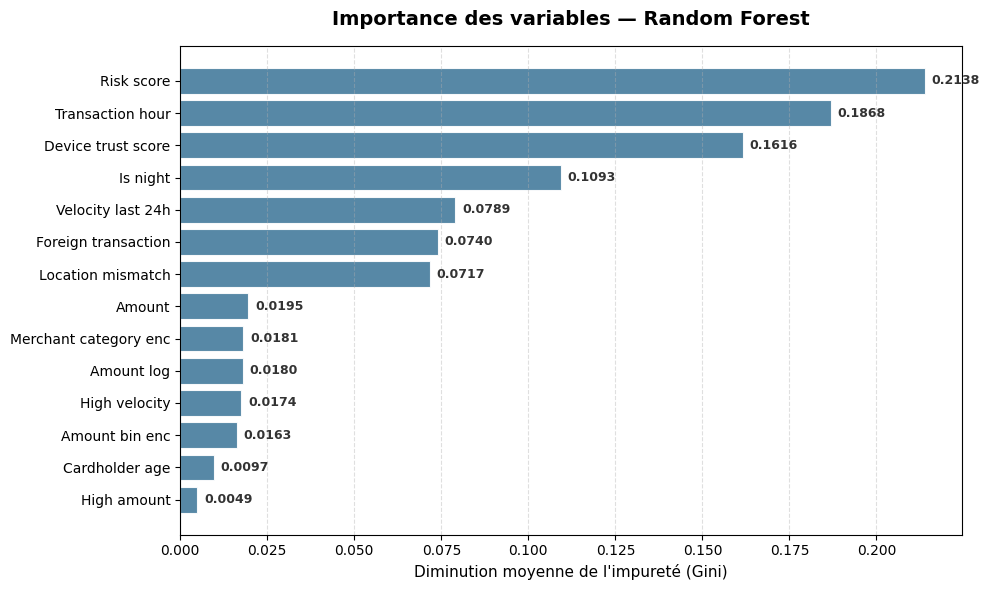


 Top 5 des variables les plus importantes :
  Risk score                     0.2138
  Transaction hour               0.1868
  Device trust score             0.1616
  Is night                       0.1093
  Velocity last 24h              0.0789


In [5]:
importances = rf.feature_importances_
feature_names = X_train.columns.tolist()

# Tri par importance décroissante
indices = np.argsort(importances)[::-1]
# Nettoyage des noms pour l'affichage
sorted_features = [feature_names[i].replace('_', ' ').capitalize() for i in indices]
sorted_importances = importances[indices]

# Graphique
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(sorted_features[::-1], sorted_importances[::-1],
               color='#457b9d', edgecolor='white', linewidth=0.8, alpha=0.9)

# Valeurs au bout des barres
for bar, val in zip(bars, sorted_importances[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=9, fontweight='bold', color='#333333')

ax.set_xlabel("Diminution moyenne de l'impureté (Gini)", fontsize=11)
ax.set_title("Importance des variables — Random Forest", fontweight='bold', fontsize=14, pad=15)
ax.grid(axis='x', alpha=0.4, linestyle='--')
plt.tight_layout()

# Sauvegarde
save_plot_path2 = PLOT_DIR / 'random_forest_feature_importances.png'
plt.savefig(save_plot_path2, bbox_inches='tight', dpi=300)
plt.show()

print("\n Top 5 des variables les plus importantes :")
for name, imp in zip(sorted_features[:5], sorted_importances[:5]):
    print(f"  {name:<30} {imp:.4f}")

Exportation du Modèle

In [ ]:
# Créer le dossier ml-models/trained/ s'il n'existe pas
MODEL_DIR = BASE_DIR / 'ml-models' / 'trained'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Chemin du fichier modèle
model_path = MODEL_DIR / 'rf_fraud_model.pkl'

# Sauvegarde
joblib.dump(rf, model_path)

print(f"Modèle Random Forest sauvegardé avec succès dans : {model_path}")

Modèle Random Forest sauvegardé avec succès dans : C:\Users\Lenovo T470\OneDrive\Documents\GitHub\fraud-detection-realtime\ml-models\trained\rf_fraud_model.pkl


: 